### Saving a ML Model
- Using:
    - Pickle  .pkl
    - Joblib  .joblib
    - .keras, .h5 - TensorFlow way of saving - Frameword by Google
    - onmx - 
    - .pt  .pth

Project - Breast Cancer Detection

1. Get the data
2. EDA first - check & analyse
    - Feature Transformation:
        - Standardisation or scale or PCA
3. Feature selection
4. Train test split
5. Modelling
6. Testing
7. Export the model
8. Check for important features
9. Write a function that take those important values (top 4 important ones) & make a prediction on those & return the predictions
10. To deploy the model on Gradio on Hugging Face
11. Learn deployment with Streamlit as well



In [53]:
pip install gradio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [55]:
pip install streamlit

   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------  9.2/9.2 MB 49.2 MB/s eta 0:00:01
   ---------------------------------------- 9.2/9.2 MB 37.0 MB/s  0:00:00
   ---------------------------------------- 0.0/797.6 kB ? eta -:--:--
   ---------------------------------------- 797.6/797.6 kB 10.7 MB/s  0:00:00
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------  11.3/11.3 MB 61.0 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 38.2 MB/s  0:00:00
   ---------------------------------------- 0.0/28.0 MB ? eta -:--:--
   ----- ---------------------------------- 4.2/28.0 MB 19.5 MB/s eta 0:00:02
   -------- ------------------------------- 5.8/28.0 MB 13.6 MB/s eta 0:00:02
   -------------- ------------------------- 10.0/28.0 MB 14.9 MB/s eta 0:00:02
   ------------------------------- -------- 21.8/28.0 MB 25.6 MB/s eta 0:00:01
   -------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd #ok
import matplotlib.pyplot as plt # ok
import seaborn as sns # ok
import numpy as np # ok
import joblib
import json
import gradio as gr
import streamlit as st

from sklearn.datasets import load_breast_cancer #ok
from sklearn.tree import DecisionTreeClassifier, plot_tree # ok
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier # ok
from sklearn.model_selection import train_test_split # ok
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # ok
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# 1. Get the data

cancer = load_breast_cancer() #dataset

df = pd.DataFrame(cancer.data, columns=cancer.feature_names) #convert to DataFrame

df["target"] = cancer.target # target column

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# 2. EDA first - check & analyse

print(df.shape)

print(df.dtypes)

print(df.info())

print(df.describe())

print(df["target"].value_counts())

print(df.isnull().sum()) #check for missing values

print(df.duplicated().sum()) #Remove Duplicate Values

df = df.drop_duplicates()

#Target 
#0 = Malignant -212
#1 = Benign - 357

(569, 31)
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symm

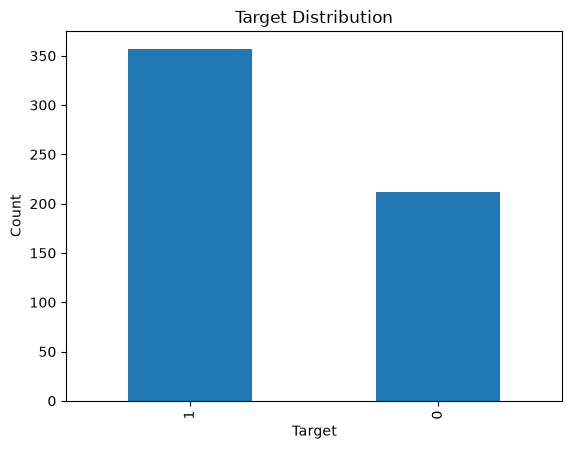

In [65]:
# Class Distribution

df["target"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

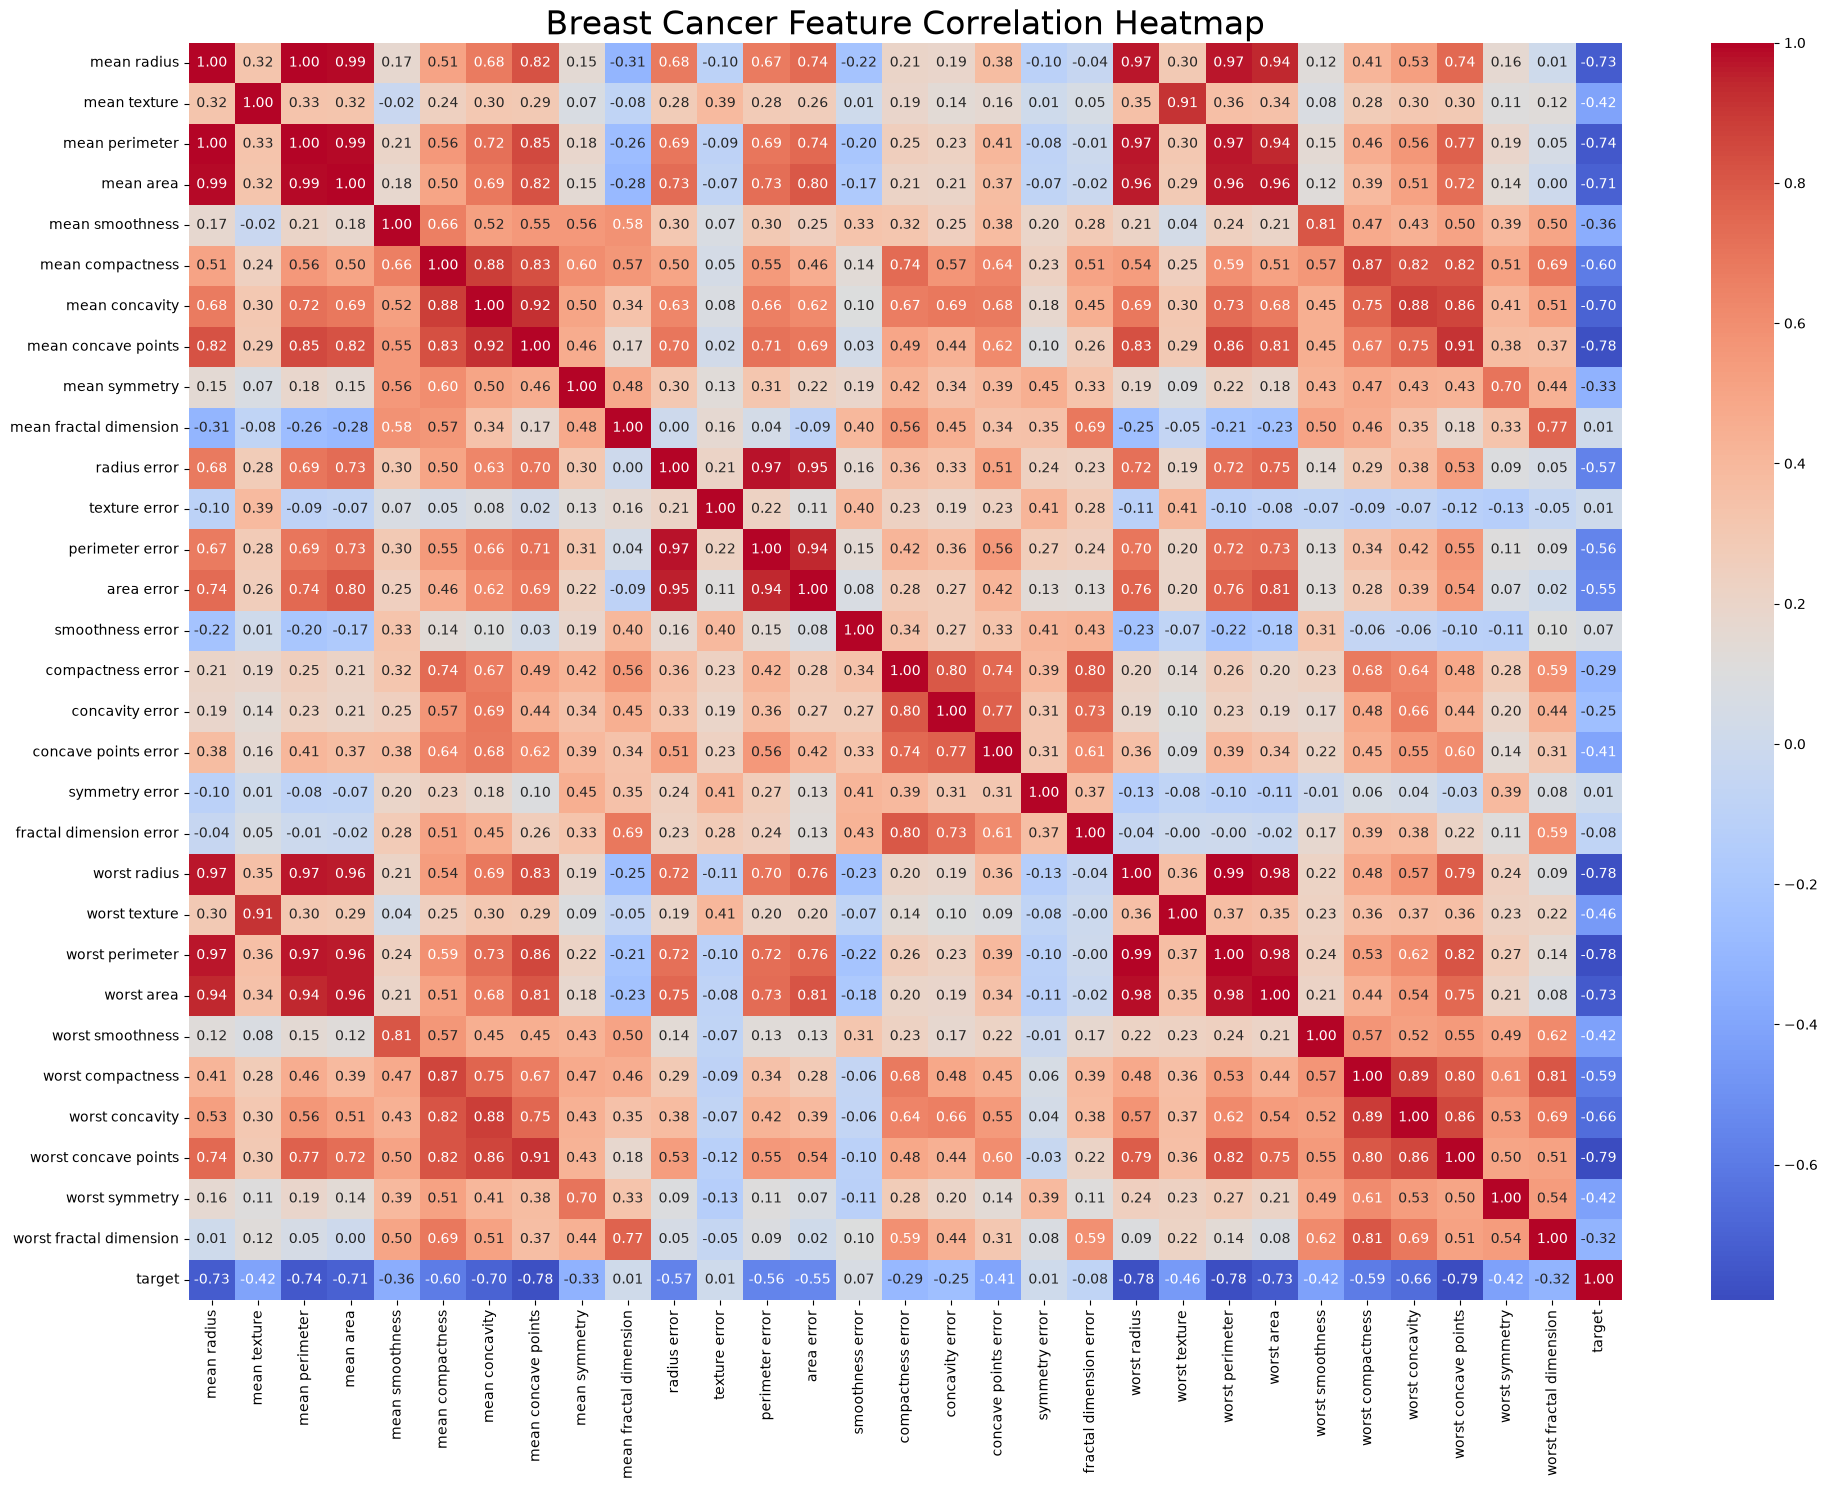

In [5]:
# Correlation

plt.figure(figsize= (20, 15))
sns.heatmap(df.corr(), annot= True, cmap = 'coolwarm', fmt = ".2f")
plt.title("Breast Cancer Feature Correlation Heatmap", fontsize = 24)
plt.tight_layout()
plt.show()


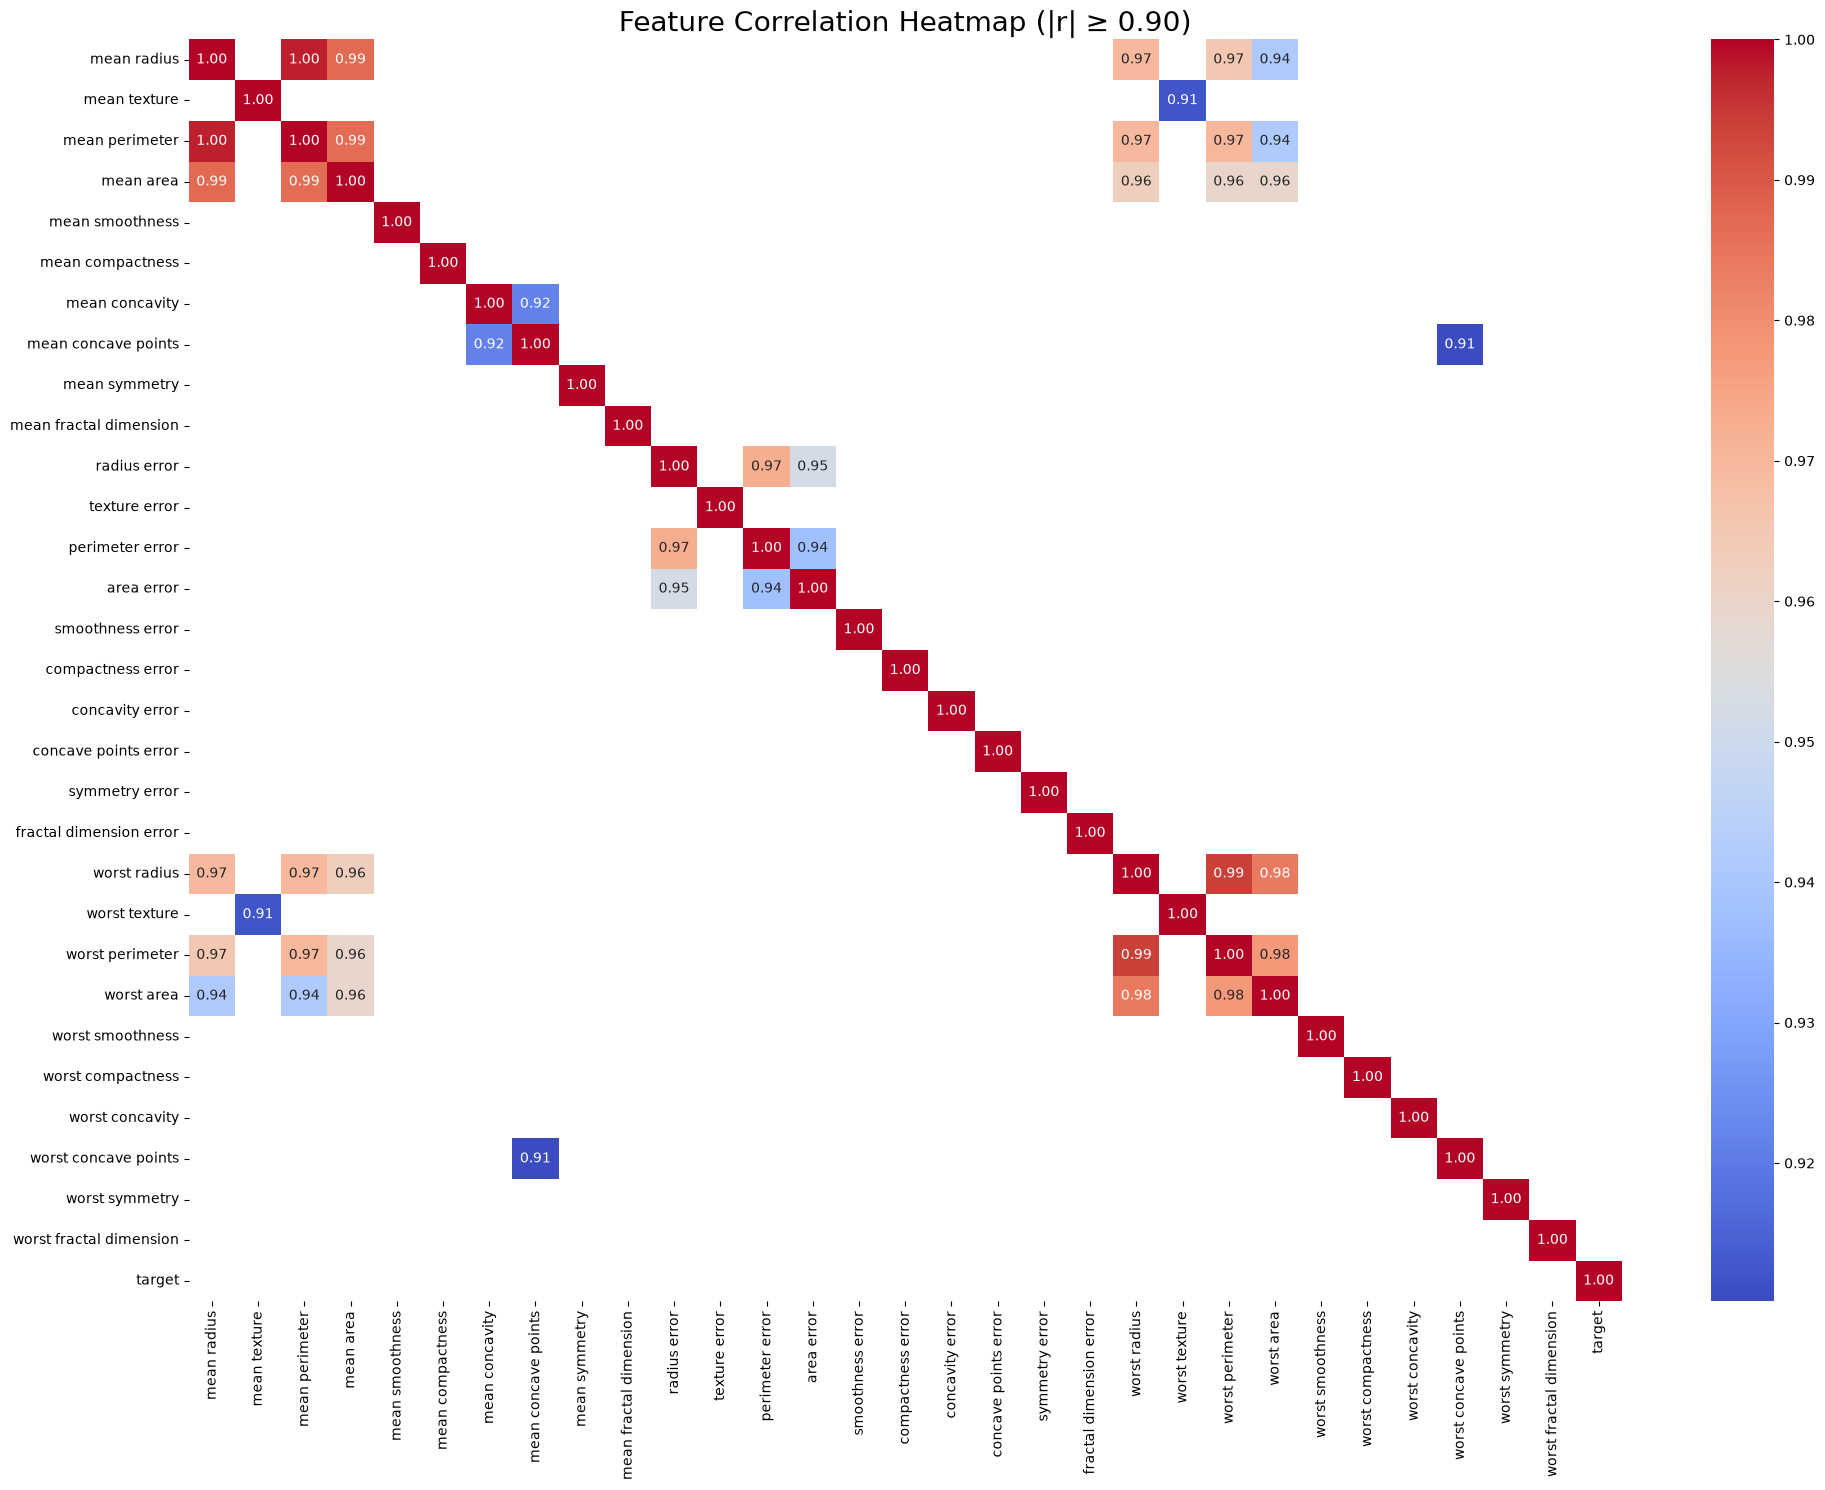

In [7]:
# Calculate correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Keep only correlations >= 0.90
threshold = 0.90
corr_filtered = corr_matrix.where(abs(corr_matrix) >= threshold)

# Plot
plt.figure(figsize=(20,15))
sns.heatmap(corr_filtered,annot=True,cmap="coolwarm",fmt=".2f",mask=corr_filtered.isnull())
plt.title("Feature Correlation Heatmap (|r| ≥ 0.90)", fontsize=20)
plt.tight_layout()
plt.show()

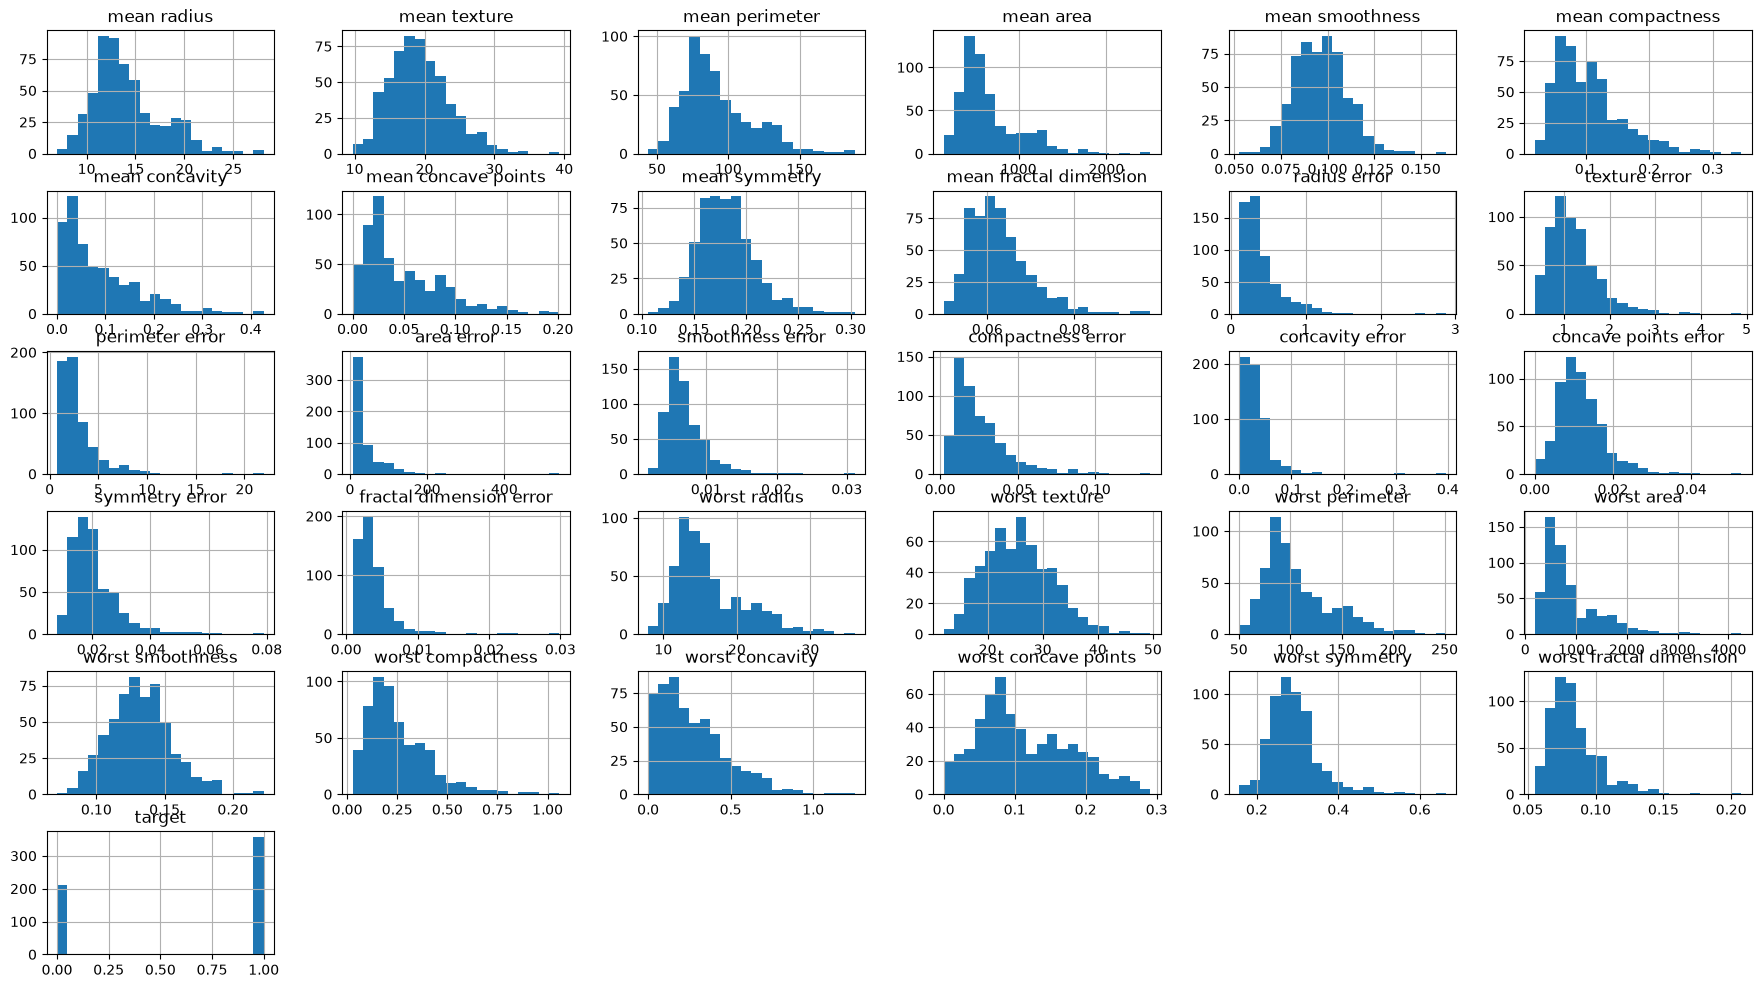

In [8]:
# Feature Distribution

df.hist(figsize=(22,12), bins=20)
plt.show()

In [ ]:
# Feature Selection

# Load dataset
cancer = load_breast_cancer()

# Features
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Target
y = cancer.target

In [67]:
# Standardization

X = df.drop("target", axis=1)
y = df["target"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

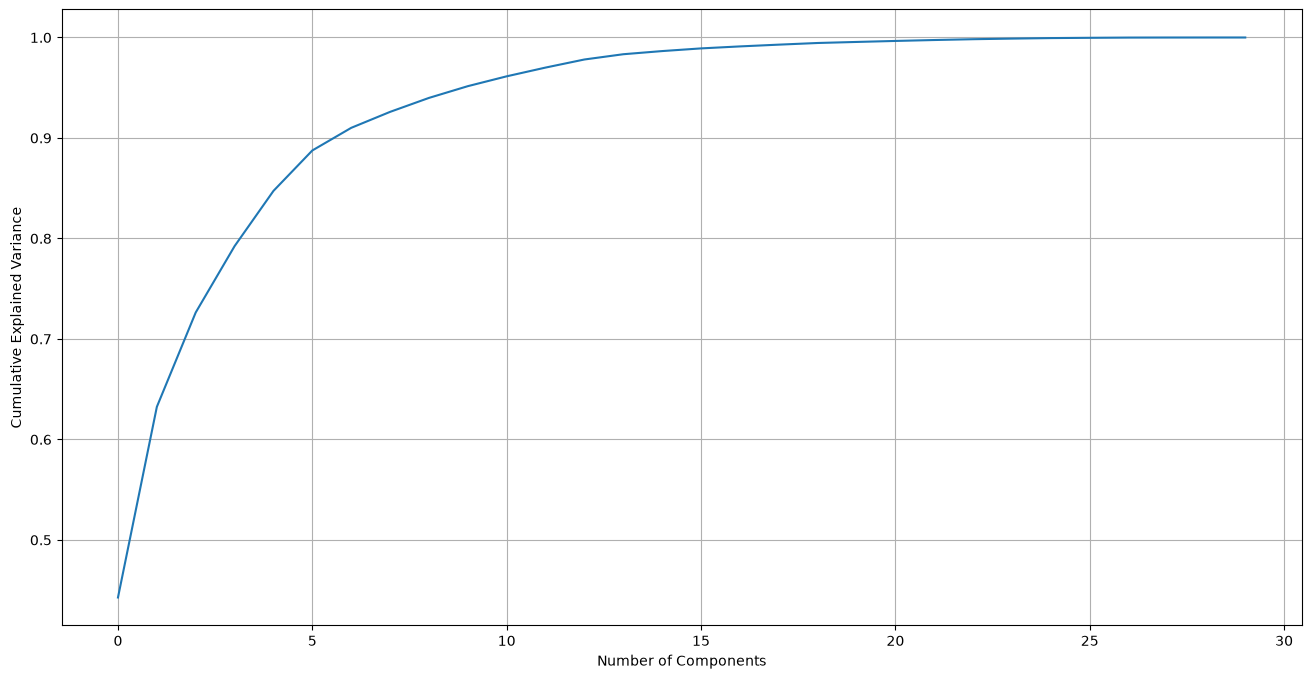

In [ ]:
# PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(16,8))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")  
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.show()

In [25]:
pca = PCA(n_components=0.95) #95% variance
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)

(569, 10)


In [28]:
# 3. Feature selection

rf = RandomForestClassifier(random_state=42)
rf.fit(X_scaled, y)
importance = pd.DataFrame({"Feature": X.columns,"Importance": rf.feature_importances_})
importance = importance.sort_values(by="Importance",ascending=False)
importance.head(5)


,Feature,Importance
23,worst area,0.139357
27,worst concave points,0.132225
7,mean concave points,0.107046
20,worst radius,0.082848
22,worst perimeter,0.080850


In [30]:
# 4. Train test split

X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42,stratify=y)

In [32]:
# 5. Modelling

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [34]:
# 6. Testing

# i. Prediction
y_pred = model.predict(X_test)
print("Predictions:", y_pred)

Predictions: [0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1
 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1
 0 1 1]


In [36]:
# ii. Accuracy Score

accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.9824561403508771


In [38]:
# iii. Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[41  1]
 [ 1 71]]


In [40]:
# iv. Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [75]:
# 7. Export the model

# To save the trained model 
from copyreg import pickle


joblib.dump(model, "breast_cancer_model.pkl")

# To save the scaler
joblib.dump(scaler, "scaler.pkl")
print("Model and scaler saved successfully.")


# To load the model
model = joblib.load("breast_cancer_model.pkl")
scaler = joblib.load("scaler.pkl")
print("Model and scaler loaded successfully.")

# To save as JSON
model_parameters = model.get_params()
with open("model_parameters.json", "w") as file:json.dump(model_parameters, file, indent=4)
print("Model parameters saved in JSON file.")


Model and scaler saved successfully.
Model and scaler loaded successfully.
Model parameters saved in JSON file.


In [72]:
# 8. Check for important features

importance = importance.sort_values(by="Importance",ascending=False)
print(importance.head(5))

                 Feature  Importance
23            worst area    0.139357
27  worst concave points    0.132225
7    mean concave points    0.107046
20          worst radius    0.082848
22       worst perimeter    0.080850


In [47]:
# 9. Write a function that take those important values (top 4 important ones) & make a prediction on those & return the predictions

top4 = importance.head(4)
print(top4)

                 Feature  Importance
23            worst area    0.139357
27  worst concave points    0.132225
7    mean concave points    0.107046
20          worst radius    0.082848


Assume the top four important features are
    - worst perimeter
    - worst radius
    - worst concave points
    - mean concave points

In [48]:
top_features = ["worst perimeter","worst radius","worst concave points","mean concave points"]

X_small = df[top_features]

scaler_small = StandardScaler()

X_small = scaler_small.fit_transform(X_small)

model_small = RandomForestClassifier(random_state=42)

model_small.fit(X_small, y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [49]:
def predict_cancer(
    worst_perimeter,
    worst_radius,
    worst_concave_points,
    mean_concave_points
):

    sample = pd.DataFrame({
        "worst perimeter":[worst_perimeter],
        "worst radius":[worst_radius],
        "worst concave points":[worst_concave_points],
        "mean concave points":[mean_concave_points]
    })

    sample = scaler_small.transform(sample)

    prediction = model_small.predict(sample)[0]

    if prediction == 1:
        return "Benign"

    return "Malignant"

In [52]:
# Example usage of the function

predict_cancer(110,20,0.15,0.09)

'Malignant'

In [56]:
# 10. To deploy the model on Gradio on Hugging Face

interface = gr.Interface(
    fn=predict_cancer,
    inputs=[
        gr.Number(label="Worst Perimeter"),
        gr.Number(label="Worst Radius"),
        gr.Number(label="Worst Concave Points"),
        gr.Number(label="Mean Concave Points")
    ],
    outputs="text",
    title="Breast Cancer Detection"
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [58]:
# 11. Learn deployment with Streamlit as well

st.title("Breast Cancer Detection")

wp = st.number_input("Worst Perimeter")
wr = st.number_input("Worst Radius")
wcp = st.number_input("Worst Concave Points")
mcp = st.number_input("Mean Concave Points")

if st.button("Predict"):

    result = predict_cancer(
        wp,
        wr,
        wcp,
        mcp
    )

    st.success(result)

2026-07-02 16:06:36.022 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 16:06:38.066 
  command:

    streamlit run C:\Users\User\AppData\Roaming\Python\Python314\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-02 16:06:38.069 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 16:06:38.072 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 16:06:38.075 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 16:06:38.078 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 16:06:38.084 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 16:06:38.096 Threa